# Test Notebebook

This notebook will contain various tests and benchmarks of Neuopt.

In [61]:
import os
import json
import torch
import pprint
import numpy as np
import random
from tensorboard_logger import Logger as TbLogger
import warnings

from problems.problem_tsp import TSP
from problems.problem_cvrp import CVRP
from agent.ppo import PPO
from tqdm.notebook import tqdm

import vrplib

Below, we initialize hyperparameters

In [62]:
from options import get_options
opts = get_options('')
opts

SIZE = 517

In [63]:
opts.problem = 'cvrp' 
opts.dummy_rate = 0.4
opts.wo_feature1 = False #feature1 corresponds to these two features : infeasibility_indicator_before_visit,infeasibility_indicator_after_visit. If wo_feature1 is False, then agent has those two features. 
opts.wo_feature3 = False #feature3 corresponds to exploration statistics (i think).
opts.wo_regular = False
opts.wo_bonus = False
opts.wo_RNN = False
opts.wo_MDP = True
opts.use_cuda = False
opts.graph_size = SIZE
opts.val_dataset='./datasets/cvrp_100.pkl'
opts.init_val_met = 'random'
opts.no_saving = True
opts.no_tb = True
opts.val_size = 10
opts.load_path = 'outputs\cvrp_270\example_training_CVRP270_20260114T162423\epoch-3.pt'
opts.device = torch.device("cuda" if opts.use_cuda else "cpu")
opts.no_progress_bar = True
opts


<>:16: SyntaxWarning: invalid escape sequence '\c'
<>:16: SyntaxWarning: invalid escape sequence '\c'
C:\Users\romai\AppData\Local\Temp\ipykernel_56752\3546624168.py:16: SyntaxWarning: invalid escape sequence '\c'
  opts.load_path = 'outputs\cvrp_270\example_training_CVRP270_20260114T162423\epoch-3.pt'


Namespace(problem='cvrp', graph_size=517, dummy_rate=0.4, eval_only=False, init_val_met='random', no_cuda=False, no_tb=True, no_saving=True, no_DDP=False, use_assert=False, seed=6666, val_m=1, stall_limit=10, k=4, wo_regular=False, wo_bonus=False, wo_RNN=False, wo_feature1=False, wo_feature3=False, wo_MDP=True, load_path='outputs\\cvrp_270\\example_training_CVRP270_20260114T162423\\epoch-3.pt', resume=None, epoch_start=0, K_epochs=3, eps_clip=0.1, T_train=200, n_step=4, batch_size=512, epoch_end=200, epoch_size=10240, val_size=10, val_batch_size=1000, val_dataset='./datasets/cvrp_100.pkl', lr_model=8e-05, lr_critic=2e-05, lr_decay=0.985, warm_up=2, max_grad_norm=0.05, train_dataset=None, v_range=6.0, critic_head_num=4, actor_head_num=4, embedding_dim=128, hidden_dim=128, n_encode_layers=3, normalization='layer', gamma=0.999, T_max=1000, no_progress_bar=True, log_dir='logs', log_step=50, record=False, output_dir='outputs', run_name='run_name_20260114T191321', checkpoint_epochs=1, wo_fea

In [64]:
from torch.utils.data import DataLoader
from problems.problem_cvrp import CVRPDataset

dataset1 = CVRPDataset(DUMMY_RATE=0.4,size=SIZE, num_samples = 2)
batch1 = next(iter(DataLoader(dataset1, batch_size=2)))


dataset2 = CVRPDataset(size = SIZE, num_samples = 2, DUMMY_RATE=0.4)
batch2 = next(iter(DataLoader(dataset2, batch_size=2)))

print(batch1.keys() == batch2.keys())
print(type(batch1) == type(batch2))
print(batch1['coordinates'].size() == batch2['coordinates'].size())
print(batch1['demand'].size() == batch2['demand'].size())
print(type(batch1['coordinates']) == type(batch2['coordinates']))
print(type(batch1['demand']) == type(batch2['demand']))

2 instances initialized.
2 instances initialized.
True
True
True
True
True
True


In [65]:
problem = CVRP(
                p_size = SIZE,
                init_val_met = opts.init_val_met,
                with_assert = opts.use_assert,
                DUMMY_RATE = opts.dummy_rate,
                k = opts.k,
                with_bonus = not opts.wo_bonus,
                with_regular = not opts.wo_regular)

# Figure out the RL algorithm
agent = PPO(problem, opts)

# Load data from load_path
assert opts.load_path is None or opts.resume is None, "Only one of load path and resume can be given"
load_path = opts.load_path if opts.load_path is not None else opts.resume
if load_path is not None:
    agent.load(load_path)

CVRP with 517 nodes and 207 dummy depots (total 724).
 Regulation: True Bonus: True Do assert: False.
 MAX 4-opt.

simpleMDP:  True
# params in Actor {'Total': 685140, 'Trainable': 685140}
# params in Critic {'Total': 191107, 'Trainable': 191107}
Distributed: False
 [*] Loading data from outputs\cvrp_270\example_training_CVRP270_20260114T162423\epoch-3.pt
 [*] Model loaded successfully (RNG states ignored).


In [66]:
import torch
from matplotlib import pyplot as plt
import matplotlib.cm as cm
import numpy as np

def plot_tour_interactive(rec, coordinates, problem):
    """
    Version Robuste : Utilise les noms (Labels) pour lier légende et graphique.
    Corrige le problème de décalage des clics.
    """
    # --- 1. Préparation des données ---
    real_seq = problem.get_order(rec.unsqueeze(0), return_solution=True)[0]
    seq_len = coordinates.size(0)
    
    if hasattr(problem, 'dummy_size') and problem.size == seq_len:
        dummy_limit = problem.dummy_size
    elif hasattr(problem, '_get_dynamic_sizes'):
        dummy_limit = problem._get_dynamic_sizes(seq_len)
    else:
        dummy_limit = int(seq_len - seq_len/(1+problem.dummy_rate))

    seq_list = real_seq.tolist()
    routes = []
    current_route = []
    
    first_depot_idx = next((i for i, x in enumerate(seq_list) if x < dummy_limit), 0)
    seq_list = seq_list[first_depot_idx:] + seq_list[:first_depot_idx]
    seq_list.append(seq_list[0])

    for node_idx in seq_list:
        if node_idx < dummy_limit:
            if current_route:
                current_route.append(node_idx)
                if len(current_route) > 2: routes.append(current_route)
                current_route = [node_idx]
            else:
                current_route = [node_idx]
        else:
            current_route.append(node_idx)

    # --- 2. Création du Plot ---
    fig, ax = plt.subplots(figsize=(12, 8))
    plt.subplots_adjust(right=0.75) 
    
    ax.scatter(coordinates[0, 0], coordinates[0, 1], marker='s', s=100, c='red', zorder=3, label='Dépôt')
    ax.scatter(coordinates[dummy_limit:, 0], coordinates[dummy_limit:, 1], marker='o', s=55, c='blue', zorder=2, label='Clients')

    colors = cm.rainbow(np.linspace(0, 1, len(routes)))
    
    # Dictionnaire : "Trajet 1" -> Objet Ligne du graphique
    lines_by_label = {}
    
    for i, route_indices in enumerate(routes):
        route_coords = coordinates[route_indices]
        
        # Masquage des liens vers le dépôt (on garde 1:-1 si possible)
        if len(route_coords) > 2:
            coords_to_plot = route_coords[1:-1]
        else:
            coords_to_plot = route_coords[1:-1]

        label_name = f'Trajet {i+1}'
        
        if len(coords_to_plot) > 1:
            line, = ax.plot(coords_to_plot[:, 0], coords_to_plot[:, 1], 
                            color=colors[i], linewidth=2, zorder=1, 
                            label=label_name)
        else:
            line, = ax.plot(route_coords[1:-1, 0], route_coords[1:-1, 1], 
                            marker='o', markersize=8, linestyle='None',
                            markeredgecolor=colors[i], markerfacecolor='none', 
                            markeredgewidth=2, zorder=1, label=label_name)
            
        lines_by_label[label_name] = line

    ax.set_title("Solution CVRP (Clic sur légende corrigé)")
    
    # --- 3. Légende Interactive (Mapping par Nom) ---
    leg = ax.legend(loc='upper left', bbox_to_anchor=(1.0, 1.0), fancybox=True, shadow=True)
    
    map_legend_to_plot = {}

    # On parcourt TOUS les éléments de la légende (Handles = Lignes/Symboles, Texts = Texte)
    for leg_handle, leg_text in zip(leg.legend_handles, leg.texts):
        label = leg_text.get_text()
        
        # Si le label correspond à une de nos routes stockées
        if label in lines_by_label:
            orig_line = lines_by_label[label]
            
            # On active le clic
            leg_handle.set_picker(True) 
            leg_handle.set_pickradius(10) # Zone de clic
            leg_text.set_picker(True)
            
            # On stocke le lien pour le Callback
            # (LigneGraphique, HandleLegende, TexteLegende)
            info = (orig_line, leg_handle, leg_text)
            map_legend_to_plot[leg_handle] = info
            map_legend_to_plot[leg_text] = info

    # --- 4. Callback ---
    def on_pick(event):
        # On récupère l'info associée à l'élément cliqué
        info = map_legend_to_plot.get(event.artist)
        if info:
            orig_line, leg_handle, leg_text = info
            
            # Bascule Visibilité
            is_visible = not orig_line.get_visible()
            orig_line.set_visible(is_visible)
            
            # Effet Visuel (Grisé)
            alpha = 1.0 if is_visible else 0.2
            leg_handle.set_alpha(alpha)
            leg_text.set_alpha(alpha)
            
            fig.canvas.draw()

    fig.canvas.mpl_connect('pick_event', on_pick)
    plt.show()

In [67]:
from utils import torch_load_cpu, get_inner_model, move_to
from problems.problem_cvrp import total_history
feasibility_history_base = [True] * (total_history)
T=1000
val_m = 1
stall_limit = 0
record = True
show_bar = False

bs, gs, _ = batch1['coordinates'].size()
batch = move_to(batch1, agent.opts.device)
batch_aug_same = problem.augment(batch, val_m, only_copy=True)
batch_aug = problem.augment(batch, val_m)
batch_feature = problem.input_feature_encoding(batch_aug)

solutions = move_to(problem.get_initial_solutions(batch_aug_same), agent.opts.device)
solution_best = solutions.clone()

obj, context = problem.get_costs(batch_aug_same, solutions, get_context = True, check_full_feasibility = True)
obj = torch.cat((obj[:,None], obj[:,None],obj[:,None]),-1).clone()
context2 = torch.zeros(bs*val_m,9).to(solutions.device);context2[:,-1] = 1
feasibility_history = torch.tensor(feasibility_history_base).view(-1,total_history).expand(bs*val_m, total_history).to(obj.device)

solution_history = [solutions.clone()]
solution_best_history = [solution_best.clone()]
obj_history = [obj.clone()]        
feasible_history_recorded = [feasibility_history[:,0]]
action = None
reward = []
stall_cnt_ins = torch.zeros(bs * val_m).to(solution_best.device)

for t in tqdm(range(T), disable = agent.opts.no_progress_bar or not show_bar, desc = 'rollout', bar_format='{l_bar}{bar:20}{r_bar}{bar:-20b}'):       

    action = agent.actor(problem,
                        batch_aug_same,
                        batch_feature,
                        solutions,
                        context,
                        context2,
                        action)[0]

    solutions, rewards, obj, feasibility_history, context, context2, info = problem.step(batch_aug_same, 
                                                                                        solutions,
                                                                                        action,
                                                                                        obj,
                                                                                        feasibility_history,
                                                                                        t,
                                                                                        weights = 0)
    index = rewards[:,0] > 0.0
    solution_best[index] = solutions[index].clone()

    # record informations
    reward.append(rewards[:,0].clone())
    obj_history.append(obj.clone())
    if record: 
        solution_history.append(solutions.clone())
        solution_best_history.append(solution_best.clone())
        feasible_history_recorded.append(feasibility_history[:,0].clone())

    # augment if stall>0 (checking every step)
    if stall_limit > 0:
        batch_aug_temp = problem.augment(batch, val_m)
        stall_cnt_ins = stall_cnt_ins * (1 - index.float()) + 1
        index_aug = stall_cnt_ins >= stall_limit
        batch_aug['coordinates'][index_aug] = batch_aug_temp['coordinates'][index_aug]
        batch_feature = problem.input_feature_encoding(batch_aug)
        stall_cnt_ins[index_aug] *= 0


# assert
best_length = problem.get_costs(batch_aug_same, solution_best, get_context = False, check_full_feasibility = True)
assert (best_length - obj[:,1] < 1e-5).all(), (best_length, obj, best_length - obj[:,1])
assert (problem.augment(batch, val_m, only_copy=True)['coordinates'] == batch_aug_same['coordinates']).all()
out = (obj[:,1].reshape(bs, val_m).min(1)[0], # batch_size, 1
       torch.stack(obj_history,1).view(bs, val_m, T+1, -1).min(1)[0], # batch_size, T, 2/3
       torch.stack(reward,1).view(bs, val_m, T).max(1)[0], # batch_size, T
       None if not record else (solution_history, solution_best_history, feasible_history_recorded)
      )

In [68]:
%matplotlib widget

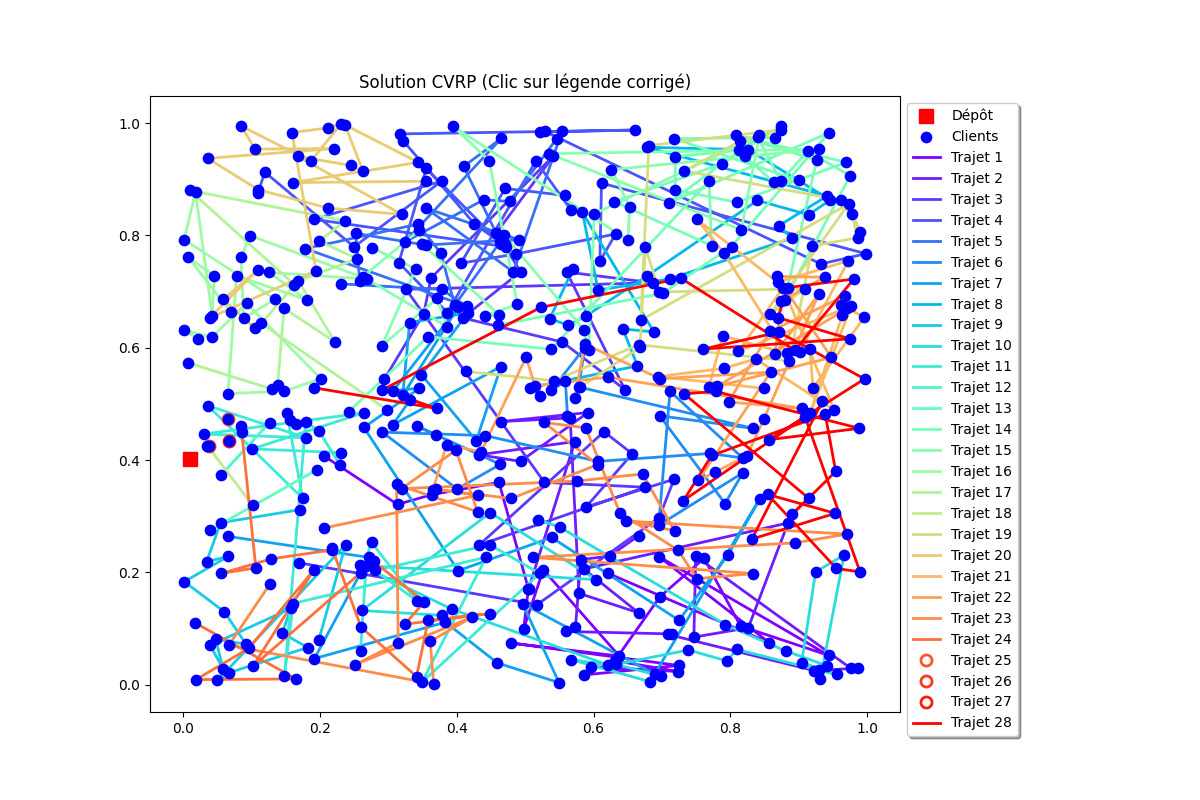

Linked list format (rec variable):
 tensor([197, 189, 404, 145, 115, 158, 226,  15,  68,  90,  14, 716, 154, 641,
        198, 156, 141,  69,  67, 466, 166,  22,  23,  24,  25,  26,  27,  28,
         29,  30,  31,  97, 206,  32,  33,  34,  35,  36, 443, 118,   1,  40,
         41,  44,  45,  46,  47,  48,  49,  50, 129,   7,  51,  70,  53,  54,
        155,  56,  57,  60,  61,  62,  93, 185,  63,  64,  65,  76, 177, 718,
        128, 240, 703,  66, 144, 451,  77,  43, 192,  78, 445, 195,  83,  37,
         75, 458,  21,  86,  87,  88,  89, 167,  81,  92, 568,  96,  12,  98,
         99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112,
         18,  94,   4,   8, 637, 299, 119, 120, 162,  71, 121,  74, 327,   0,
        123, 126, 127, 130,   3, 132, 133, 134, 135, 136, 137, 138, 139, 149,
        142, 191, 152, 402, 400, 146, 147, 148, 178, 483, 173, 521,  10, 188,
        150, 205,  91, 609, 131,  58, 667, 323, 163, 418, 184, 168,   9,  42,
        169, 170, 171, 159, 

In [69]:
coordinates_first = batch['coordinates'][0]
plot_tour_interactive(solution_best[0], coordinates_first, problem)
print('Linked list format (rec variable):\n', solution_best[0])
print('\nHere, the linked list format means:')
for i in range(10):
    print(f'edge {i}-{solution_best[0,i]} is in the solution')

real_seq = problem.get_order(solution_best, return_solution = True)
print('\nReal solution after decoding (node visited in sequence):\n', real_seq[0])
best_length = problem.get_costs(batch_aug_same, solution_best, get_context = False, check_full_feasibility = True)
print(best_length)

In [70]:
%pip install pyvrp
from pyvrp.plotting import plot_coordinates

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip
